In [154]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from src import corpus,keymap,optimization

from tqdm import tqdm
import numpy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
char_freqs,bigram_matrix,chars=corpus.get_matrix_from_json("ressources/fre_en.json")
print(len(chars))
ergo_chords=keymap.generate_ergonomic_chords(3)
print(len(ergo_chords))

POP_SIZE =300  # Population size for genetic algorithm
GENS = 150  # Number of generations
MUTATION_RATE = 1  # Probability of mutation
MAX_MUTATION=10
IND_SIZE=len(ergo_chords)
layout_cost=lambda layout: (float(optimization.layout_cost(layout,char_freqs,bigram_matrix,ergo_chords)),)
mutate= lambda child: (keymap.mutate(child,MUTATION_RATE,MAX_MUTATION),)
crossover= lambda p1,p2:(keymap.crossover(p1, p2),keymap.crossover(p2, p1))


36
92


In [156]:
import random

from deap import base
from deap import creator
from deap import tools

from deap import algorithms

# creator.create("FitnessMin", base.Fitness, weights=(1.0,))
# creator.create("Individual", list, fitness=creator.FitnessMin)

creator.create("Fitness", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Fitness)

toolbox = base.Toolbox()
# toolbox.register("attr_int", random.random)
# toolbox.register("individual", random.sample,list(range(IND_SIZE)), IND_SIZE)


# toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(IND_SIZE), IND_SIZE)
toolbox.register("individual", tools.initIterate, creator.Individual,
                 toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", layout_cost)
toolbox.register("mate", crossover)
toolbox.register("mutate", mutate)
toolbox.register("select", tools.selNSGA2)

In [157]:
random.seed(64)
NGEN = GENS
MU = POP_SIZE
LAMBDA = 200
CXPB = 0.5
MUTPB = 0.5

pop = toolbox.population(n=MU)
hof = tools.ParetoFront()
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean, axis=0)
stats.register("std", numpy.std, axis=0)
stats.register("min", numpy.min, axis=0)
stats.register("max", numpy.max, axis=0)

pop, logbook=algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats,
                            halloffame=hof)

# pop, stats, hof

gen	nevals	avg          	std        	min         	max          
0  	300   	[13.95938027]	[2.9837903]	[6.43622318]	[22.54796433]
1  	200   	[12.06011206]	[1.77110895]	[6.43622318]	[14.58888931]
2  	200   	[11.06190684]	[1.46673484]	[6.43622318]	[12.6231909] 
3  	200   	[10.20928184]	[1.27231344]	[6.39017545]	[11.59243165]
4  	200   	[9.39227954] 	[1.10211433]	[6.39017545]	[10.62569453]
5  	200   	[8.6362019]  	[1.01169976]	[4.38729379]	[9.63821342] 
6  	200   	[8.03429173] 	[0.9857065] 	[4.31808127]	[9.45368487] 
7  	200   	[7.41609135] 	[0.91314966]	[3.45848459]	[8.52828316] 
8  	200   	[6.85384352] 	[0.81480965]	[3.45848459]	[7.61529189] 
9  	200   	[6.43723814] 	[0.82963697]	[3.45848459]	[7.47397112] 
10 	200   	[5.94643983] 	[0.76923703]	[2.44121393]	[6.59081353] 
11 	200   	[5.64594358] 	[0.7990697] 	[2.44121393]	[6.48790045] 
12 	200   	[5.17120865] 	[0.76934783]	[2.37484338]	[6.37922915] 
13 	200   	[4.80848979] 	[0.75156113]	[1.44195157]	[5.51016004] 
14 	200   	[4.48471718] 	[0

In [158]:
top10 = tools.selBest(pop, k=10)
gen, minimum = logbook.select("gen", "min")

Text(0.5, 1.0, '[0.10011697]')

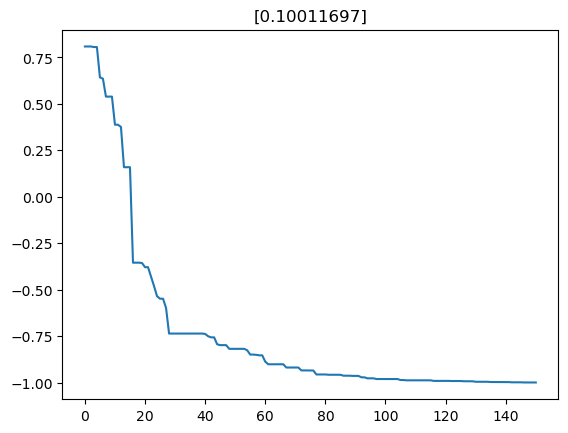

In [159]:
plt.plot(gen,np.log10(minimum))
plt.title(minimum[-1])

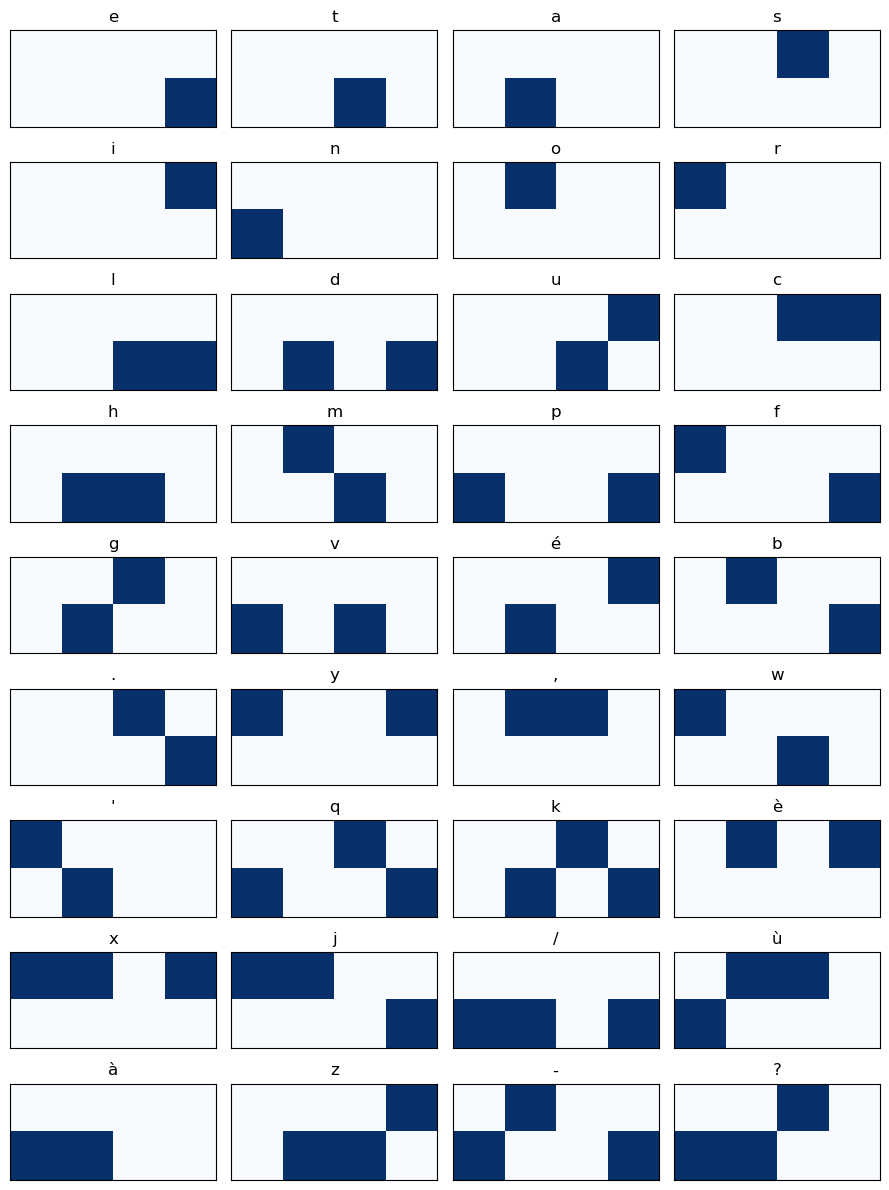

In [160]:
keymap.plot_layout_nicer(top10[0],ergo_chords,chars)